In [1]:
import pandas as pd

# Load the cleaned CSV
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Inspect the dataset
print("Dataset Shape:", df.shape)  # Number of rows and columns
print("\nColumns:\n", df.columns)  # Column names
print("\nFirst 5 rows:\n", df.head())  # Preview first 5 rows

Dataset Shape: (1205, 13)

Columns:
 Index(['SEX', 'AGE', 'RESIDENT', 'dx 1', 'Code', 'dx 2', 'Code.1', 'dx 3',
       'Code.2', 'dx 4', 'Code.3', 'OUTCOME', 'DOD'],
      dtype='object')

First 5 rows:
       SEX  AGE    RESIDENT                                   dx 1  \
0    Male   18      Street                   Acute encephalopathy   
1    Male   29       Kibos          Disseminated TB (Respiratory)   
2    Male   71      Kobura                                    NaN   
3    Male   20  Pembe Tatu                                    NaN   
4  Female   75     Nyahera  Chronic Obstructive pulmonary disease   

                      Code             dx 2               Code.1  \
0  G93.4 (nervous system )  Disseminated TB  A16.9 (Respiratory)   
1                    A16.9         Lymphoma    C85.9 (neoplasms)   
2                      NaN              NaN                  NaN   
3                      NaN              NaN                  NaN   
4     J44.9 ( respiratory)              N

In [2]:
# ===============================
# STEP 1 — Understand the Dataset
# Robust version to avoid KeyErrors
# ===============================

import pandas as pd

# Load the cleaned dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# 1.1 Inspect dataset structure
print("Dataset Shape (rows, columns):", df.shape)
print("\nColumns in the dataset:")
print(df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

# 1.2 Standardize column names (remove spaces, lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("\nStandardized Columns:")
print(df.columns.tolist())

# 1.3 Check data types
print("\nData types:\n", df.dtypes)

# 1.4 Summary statistics for numeric columns (AGE)
if 'age' in df.columns:
    print("\nSummary statistics for AGE:\n", df['age'].describe())
else:
    print("\nColumn 'AGE' not found in dataset.")

# 1.5 Count unique values for categorical columns
for cat_col in ['sex','resident']:
    if cat_col in df.columns:
        print(f"\nUnique values in {cat_col.upper()}:\n", df[cat_col].value_counts())
    else:
        print(f"\nColumn '{cat_col}' not found in dataset.")

# 1.6 Quick overview of clinical variables (dx1-dx4)
clinical_cols = [col for col in df.columns if 'dx' in col]
print("\nClinical columns detected:", clinical_cols)

for col in clinical_cols:
    print(f"\nTop 10 values in {col}:\n", df[col].value_counts().head(10))

# 1.7 Overview of outcomes
for outcome_col in ['outcome','dod']:
    if outcome_col in df.columns:
        print(f"\nOverview of {outcome_col.upper()}:")
        print(df[outcome_col].value_counts(dropna=False))
    else:
        print(f"\nColumn '{outcome_col}' not found in dataset.")

Dataset Shape (rows, columns): (1205, 13)

Columns in the dataset:
['SEX', 'AGE', 'RESIDENT', 'dx 1', 'Code', 'dx 2', 'Code.1', 'dx 3', 'Code.2', 'dx 4', 'Code.3', 'OUTCOME', 'DOD']

First 5 rows:
       SEX  AGE    RESIDENT                                   dx 1  \
0    Male   18      Street                   Acute encephalopathy   
1    Male   29       Kibos          Disseminated TB (Respiratory)   
2    Male   71      Kobura                                    NaN   
3    Male   20  Pembe Tatu                                    NaN   
4  Female   75     Nyahera  Chronic Obstructive pulmonary disease   

                      Code             dx 2               Code.1  \
0  G93.4 (nervous system )  Disseminated TB  A16.9 (Respiratory)   
1                    A16.9         Lymphoma    C85.9 (neoplasms)   
2                      NaN              NaN                  NaN   
3                      NaN              NaN                  NaN   
4     J44.9 ( respiratory)              NaN    

In [3]:
# ===============================
# STEP 2 — Data Cleaning
# ===============================

import numpy as np
import pandas as pd

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 2.1 Replace placeholder values '---' with NaN
df.replace('---', np.nan, inplace=True)

# 2.2 Standardize text fields
# Example: unify variations in diagnoses
df['dx_1'] = df['dx_1'].str.title().str.strip()
df['dx_2'] = df['dx_2'].str.title().str.strip()
df['dx_3'] = df['dx_3'].str.title().str.strip()
df['dx_4'] = df['dx_4'].str.title().str.strip()
df['outcome'] = df['outcome'].str.lower().str.strip()
df['resident'] = df['resident'].str.title().str.strip()

# 2.3 Convert DOD to datetime
df['dod'] = pd.to_datetime(df['dod'], errors='coerce')

# 2.4 Handle missing demographic values
df['sex'].fillna('Unknown', inplace=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 2.5 Drop exact duplicate rows
df.drop_duplicates(inplace=True)

# 2.6 Quick check after cleaning
print("After Cleaning:")
print("Dataset Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nUnique outcomes:\n", df['outcome'].value_counts(dropna=False))

After Cleaning:
Dataset Shape: (1199, 13)

Missing values per column:
 sex            0
age            0
resident       9
dx_1          16
code          37
dx_2         431
code.1       472
dx_3         802
code.2       835
dx_4        1056
code.3      1067
outcome        5
dod          248
dtype: int64

Unique outcomes:
 outcome
discharge             951
dead                  227
referred               14
NaN                     5
unknownorabsconded      2
Name: count, dtype: int64


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\3253517456.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].fillna('Unknown', inplace=True)


In [4]:
# ===============================
# STEP 3 — Creating Analytical Variables
# ===============================

# Neurological keywords (example, can expand as needed)
neuro_keywords = ['encephalopathy', 'encephalitis', 'meningitis', 'parkinson', 'stroke', 'neuropathy', 'convulsive']

# Function to flag neurological conditions
def neurological_flag(row):
    for col in ['dx_1','dx_2','dx_3','dx_4']:
        val = str(row[col]).lower()
        if any(word in val for word in neuro_keywords):
            return 1
    return 0

# Function to flag Parkinson's Disease
def parkinsons_flag(row):
    for col in ['dx_1','dx_2','dx_3','dx_4']:
        val = str(row[col]).lower()
        if 'parkinson' in val:
            return 1
    return 0

# Apply flags
df['neurological_flag'] = df.apply(neurological_flag, axis=1)
df['parkinsons_flag'] = df.apply(parkinsons_flag, axis=1)

# Age groups
bins = [0, 19, 39, 59, 79, 120]
labels = ['<20','20-39','40-59','60-79','80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Clean outcome
df['outcome_clean'] = df['outcome'].fillna('unknown')

# Count number of diagnoses per patient
df['num_diagnoses'] = df[['dx_1','dx_2','dx_3','dx_4']].notna().sum(axis=1)

# Primary diagnosis
df['primary_diagnosis'] = df['dx_1']

# Quick check
print(df[['sex','age','age_group','resident','primary_diagnosis','neurological_flag','parkinsons_flag','num_diagnoses','outcome_clean']].head(10))

       sex  age age_group        resident  \
0     Male   18       <20          Street   
1     Male   29     20-39           Kibos   
2     Male   71     60-79          Kobura   
3     Male   20     20-39      Pembe Tatu   
4   Female   75     60-79         Nyahera   
5     Male   56     40-59         Nyawita   
6     Male   32     20-39         Otonglo   
7     Male   30     20-39          Kisumu   
8     Male   99       80+  Test Residence   
11    Male   18       <20          Street   

                        primary_diagnosis  neurological_flag  parkinsons_flag  \
0                    Acute Encephalopathy                  1                0   
1           Disseminated Tb (Respiratory)                  0                0   
2                                     NaN                  0                0   
3                                     NaN                  0                0   
4   Chronic Obstructive Pulmonary Disease                  0                0   
5                 

Total Admissions: 1199

Age Statistics:
 count    1199.000000
mean       45.689741
std        21.052177
min        12.000000
25%        29.000000
50%        42.000000
75%        63.000000
max        99.000000
Name: age, dtype: float64

Gender Distribution:
 sex
Female    618
Male      581
Name: count, dtype: int64

Age Group Distribution:
 age_group
<20      131
20-39    410
40-59    316
60-79    249
80+       93
Name: count, dtype: int64

Outcome Distribution:
 outcome_clean
discharge             951
dead                  227
referred               14
unknown                 5
unknownorabsconded      2
Name: count, dtype: int64


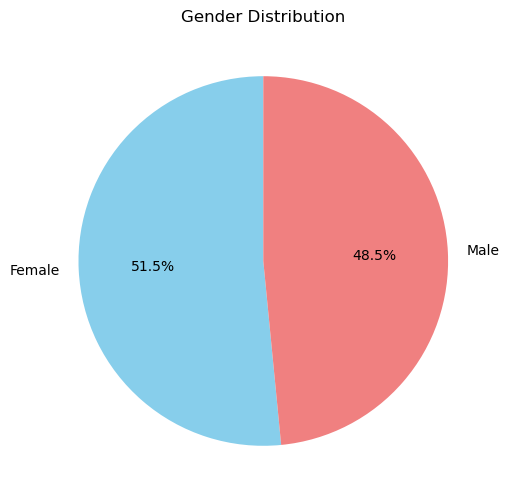

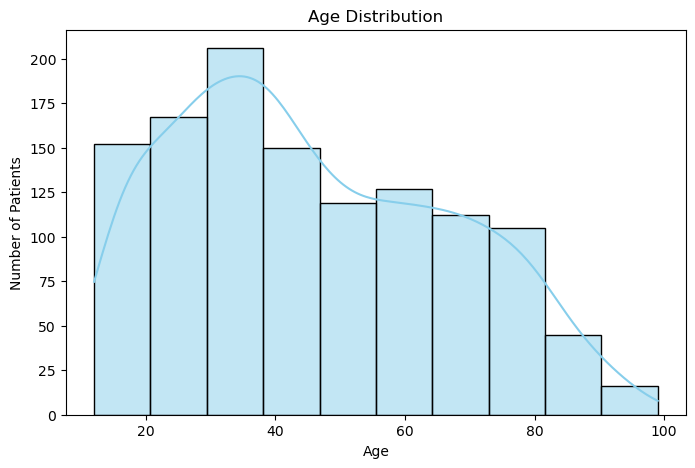

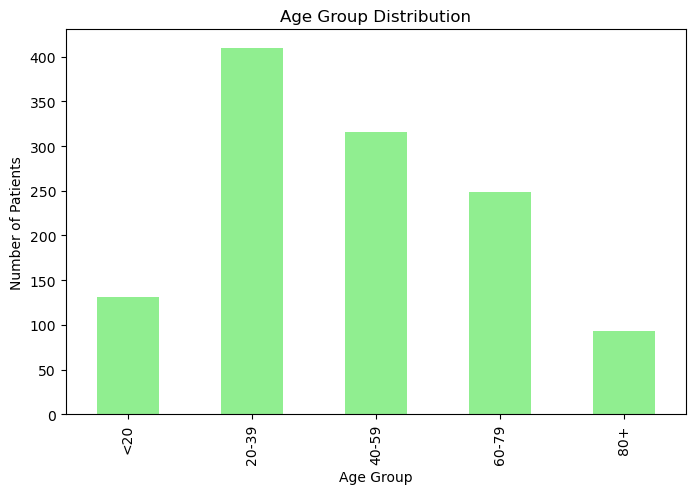

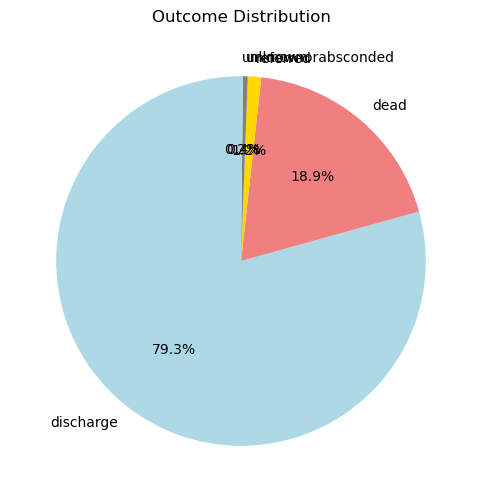

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Total admissions
total_admissions = df.shape[0]
print("Total Admissions:", total_admissions)

# 2. Age statistics
age_stats = df['age'].describe()
print("\nAge Statistics:\n", age_stats)

# 3. Gender distribution
gender_counts = df['sex'].value_counts()
print("\nGender Distribution:\n", gender_counts)

# 4. Age group distribution
age_group_counts = df['age_group'].value_counts().sort_index()
print("\nAge Group Distribution:\n", age_group_counts)

# 5. Outcome distribution
outcome_counts = df['outcome_clean'].value_counts()
print("\nOutcome Distribution:\n", outcome_counts)

# ===============================
# Visualizations
# ===============================

# Gender pie chart
plt.figure(figsize=(6,6))
gender_counts.plot.pie(autopct='%1.1f%%', colors=['skyblue','lightcoral'], startangle=90)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

# Age histogram
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

# Age group bar chart
plt.figure(figsize=(8,5))
age_group_counts.plot.bar(color='lightgreen')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.show()

# Outcome pie chart
plt.figure(figsize=(6,6))
outcome_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue','lightcoral','gold','grey'])
plt.title('Outcome Distribution')
plt.ylabel('')
plt.show()

In [8]:
import pandas as pd

# Load the cleaned CSV
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Inspect columns to help identify diagnosis columns
print("Columns in dataset:\n", df.columns)

# Ensure admission_date is datetime if present
if 'admission_date' in df.columns:
    df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')

total_patients = len(df)

# -----------------------------
# 1. Age Distribution
# -----------------------------
age_bins = [18, 31, 46, 61, 100]
age_labels = ['18–30', '31–45', '46–60', '>60']
if 'AGE' in df.columns:
    df['Age_Group'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_table = df['Age_Group'].value_counts().sort_index().reset_index()
    age_table.columns = ['Age Group', 'Number of Patients']
    age_table['Percentage'] = (age_table['Number of Patients'] / total_patients * 100).round(2)
    print("\n1. Age Distribution Table:\n", age_table)
else:
    print("\nNo AGE column found.")

# -----------------------------
# 2. Gender Distribution
# -----------------------------
if 'SEX' in df.columns:
    gender_table = df['SEX'].value_counts().reset_index()
    gender_table.columns = ['Gender', 'Number of Patients']
    gender_table['Percentage'] = (gender_table['Number of Patients'] / total_patients * 100).round(2)
    print("\n2. Gender Distribution Table:\n", gender_table)
else:
    print("\nNo SEX column found.")

# -----------------------------
# 3. Residence Distribution (Top 10)
# -----------------------------
if 'RESIDENT' in df.columns:
    res_table = df['RESIDENT'].value_counts().head(10).reset_index()
    res_table.columns = ['Residence', 'Number of Patients']
    res_table['Percentage'] = (res_table['Number of Patients'] / total_patients * 100).round(2)
    print("\n3. Top 10 Patient Residences Table:\n", res_table)
else:
    print("\nNo RESIDENT column found.")

# -----------------------------
# 4. Top 10 Primary Diagnoses
# -----------------------------
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]
if diagnosis_cols:
    all_diagnoses = df[diagnosis_cols].melt(value_name='Diagnosis')['Diagnosis'].dropna()
    disease_table = all_diagnoses.value_counts().head(10).reset_index()
    disease_table.columns = ['Primary Diagnosis', 'Number of Patients']
    disease_table['Percentage'] = (disease_table['Number of Patients'] / total_patients * 100).round(2)
    print("\n4. Top 10 Primary Diagnoses Table:\n", disease_table)
else:
    print("\nNo diagnosis columns found.")

# -----------------------------
# 5. Monthly Admissions (if admission_date exists)
# -----------------------------
if 'admission_date' in df.columns:
    monthly_table = df.groupby(df['admission_date'].dt.to_period('M')).size().reset_index()
    monthly_table.columns = ['Month', 'Number of Admissions']
    monthly_table['Month'] = monthly_table['Month'].dt.strftime('%Y-%m')
    monthly_table['Percentage'] = (monthly_table['Number of Admissions'] / total_patients * 100).round(2)
    print("\n5. Monthly Admissions Table:\n", monthly_table)
else:
    print("\nNo 'admission_date' column found for time trends analysis.")

Columns in dataset:
 Index(['SEX', 'AGE', 'RESIDENT', 'dx 1', 'Code', 'dx 2', 'Code.1', 'dx 3',
       'Code.2', 'dx 4', 'Code.3', 'OUTCOME', 'DOD'],
      dtype='object')

1. Age Distribution Table:
   Age Group  Number of Patients  Percentage
0     18–30                 260       21.58
1     31–45                 309       25.64
2     46–60                 217       18.01
3       >60                 322       26.72

2. Gender Distribution Table:
    Gender  Number of Patients  Percentage
0  Female                 620       51.45
1    Male                 585       48.55

3. Top 10 Patient Residences Table:
     Residence  Number of Patients  Percentage
0    Nyalenda                 113        9.38
1    Manyatta                  89        7.39
2  Nyamasaria                  54        4.48
3        Seme                  37        3.07
4     Otonglo                  31        2.57
5      Kajulu                  28        2.32
6       Ahero                  28        2.32
7      Rabuor  

## obective 2

In [9]:
import pandas as pd

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Automatically detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# -----------------------------
# 1. Identify Neurological Patients
# -----------------------------
# For simplicity, assume neurological conditions contain keywords
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)

neurological_df = df[df['Neurological']]

# -----------------------------
# 2. Flag Parkinson’s Disease Patients
# -----------------------------
parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# -----------------------------
# 3. Proportions
# -----------------------------
total_neuro = len(neurological_df)
total_admissions = len(df)
total_parkinson = neurological_df['Parkinson'].sum()

proportion_neuro = total_parkinson / total_neuro * 100 if total_neuro else 0
proportion_all = total_parkinson / total_admissions * 100 if total_admissions else 0

print(f"\nProportion of Parkinson’s patients among neurological patients: {proportion_neuro:.2f}%")
print(f"Proportion of Parkinson’s patients among all hospital admissions: {proportion_all:.2f}%")

# -----------------------------
# 4. Parkinson’s Patient Characteristics
# -----------------------------
total_parkinson = neurological_df[neurological_df['Parkinson']]

# Age distribution
if 'AGE' in df.columns:
    age_bins = [18, 31, 46, 61, 100]
    age_labels = ['18–30', '31–45', '46–60', '>60']
    total_parkinson['Age_Group'] = pd.cut(total_parkinson['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_table = total_parkinson['Age_Group'].value_counts().sort_index().reset_index()
    age_table.columns = ['Age Group', 'Number of Patients']
    age_table['Percentage'] = (age_table['Number of Patients'] / len(total_parkinson) * 100).round(2)
    print("\nParkinson’s Patients Age Distribution Table:\n", age_table)

# Gender distribution
if 'SEX' in df.columns:
    gender_table = total_parkinson['SEX'].value_counts().reset_index()
    gender_table.columns = ['Gender', 'Number of Patients']
    gender_table['Percentage'] = (gender_table['Number of Patients'] / len(total_parkinson) * 100).round(2)
    print("\nParkinson’s Patients Gender Distribution Table:\n", gender_table)

# Residence distribution (Top 10)
if 'RESIDENT' in df.columns:
    res_table = total_parkinson['RESIDENT'].value_counts().head(10).reset_index()
    res_table.columns = ['Residence', 'Number of Patients']
    res_table['Percentage'] = (res_table['Number of Patients'] / len(total_parkinson) * 100).round(2)
    print("\nParkinson’s Patients Top 10 Residences Table:\n", res_table)


Proportion of Parkinson’s patients among neurological patients: 1.47%
Proportion of Parkinson’s patients among all hospital admissions: 0.08%

Parkinson’s Patients Age Distribution Table:
   Age Group  Number of Patients  Percentage
0     18–30                   0         0.0
1     31–45                   0         0.0
2     46–60                   0         0.0
3       >60                   1       100.0

Parkinson’s Patients Gender Distribution Table:
    Gender  Number of Patients  Percentage
0  Female                   1       100.0

Parkinson’s Patients Top 10 Residences Table:
   Residence  Number of Patients  Percentage
0     Arina                   1       100.0


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\209673993.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\209673993.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_parkinson['Age_Group'] = pd.cut(total_parkinson['AGE'], bins=age_bins, labels=age_labels, right=False)


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\651571980.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = df.groupby(['Age_Group', 'SEX']).size().unstack(fill_value=0)


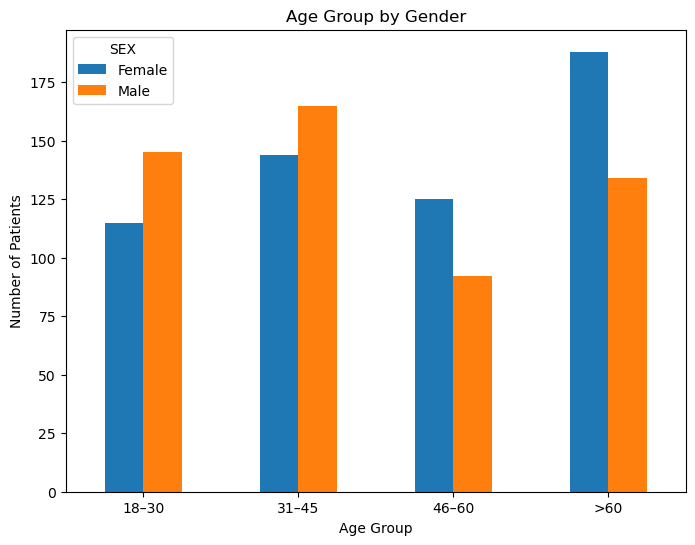

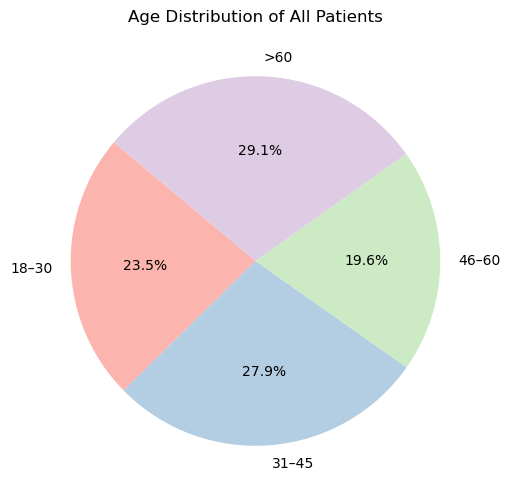

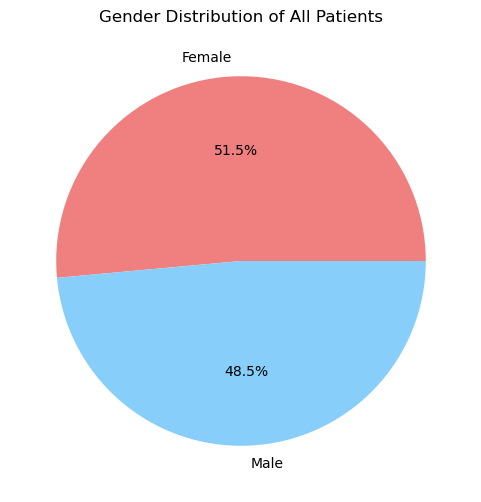

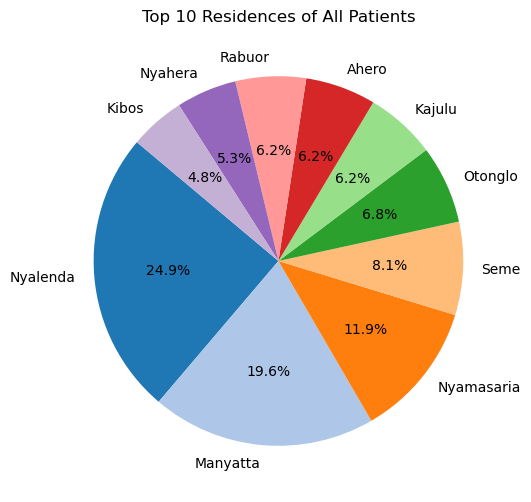

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\651571980.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(


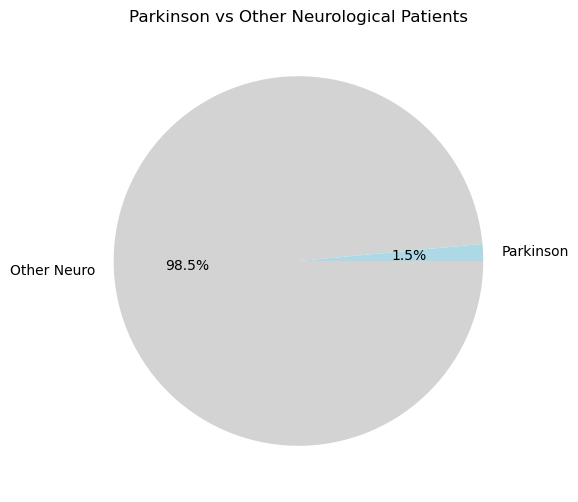

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\651571980.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parkinson_df['Age_Group'] = pd.cut(parkinson_df['AGE'], bins=age_bins, labels=age_labels, right=False)


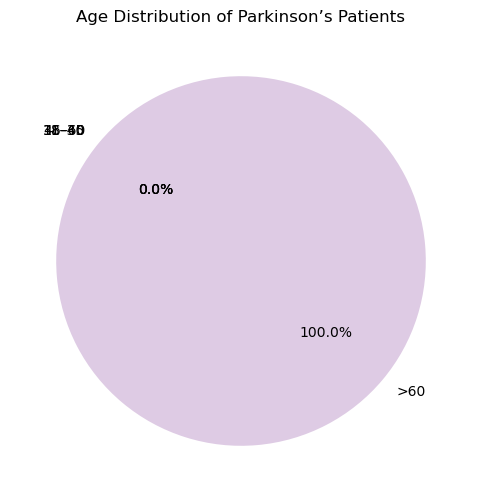

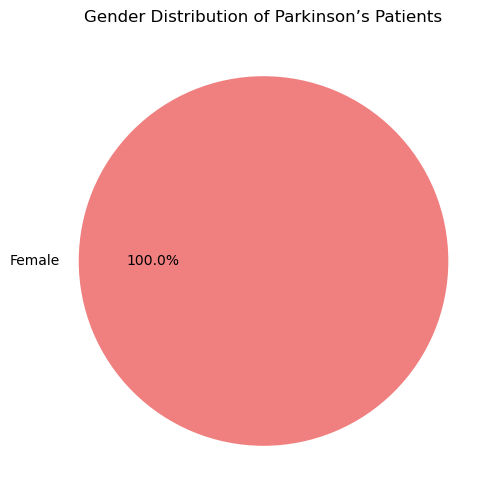

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\651571980.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = parkinson_df.groupby(['Age_Group', 'SEX']).size().unstack(fill_value=0)


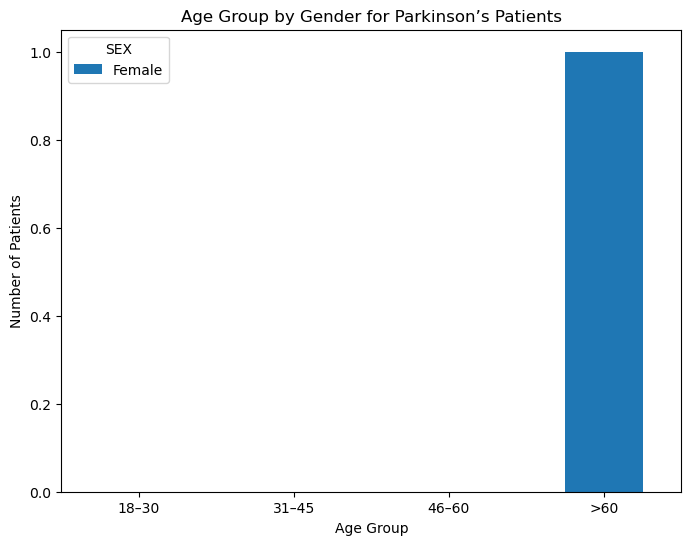

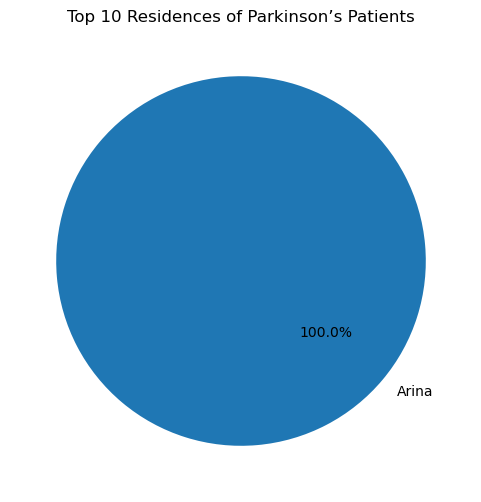

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Automatically detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# -----------------------------
# STEP 5: Admissions Patterns
# -----------------------------

# Age groups
age_bins = [18, 31, 46, 61, 100]
age_labels = ['18–30', '31–45', '46–60', '>60']
if 'AGE' in df.columns:
    df['Age_Group'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)
    # Compound bar: Age group by gender
    if 'SEX' in df.columns:
        age_gender = df.groupby(['Age_Group', 'SEX']).size().unstack(fill_value=0)
        age_gender.plot(kind='bar', figsize=(8,6))
        plt.title('Age Group by Gender')
        plt.ylabel('Number of Patients')
        plt.xlabel('Age Group')
        plt.xticks(rotation=0)
        plt.show()
    # Pie chart for Age distribution
    age_counts = df['Age_Group'].value_counts().sort_index()
    plt.figure(figsize=(6,6))
    plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
    plt.title('Age Distribution of All Patients')
    plt.show()

# Gender pie chart
if 'SEX' in df.columns:
    gender_counts = df['SEX'].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral','lightskyblue'])
    plt.title('Gender Distribution of All Patients')
    plt.show()

# Top 10 Residences pie chart
if 'RESIDENT' in df.columns:
    res_counts = df['RESIDENT'].value_counts().head(10)
    plt.figure(figsize=(6,6))
    plt.pie(res_counts, labels=res_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
    plt.title('Top 10 Residences of All Patients')
    plt.show()

# -----------------------------
# STEP 6: Parkinson’s Disease
# -----------------------------
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)
neurological_df = df[df['Neurological']]

parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# Pie chart: Parkinson vs Other Neurological
total_parkinson = neurological_df['Parkinson'].sum()
total_neuro = len(neurological_df)
plt.figure(figsize=(6,6))
plt.pie([total_parkinson, total_neuro - total_parkinson],
        labels=['Parkinson', 'Other Neuro'],
        autopct='%1.1f%%',
        colors=['lightblue','lightgray'])
plt.title('Parkinson vs Other Neurological Patients')
plt.show()

# Parkinson’s patient characteristics
parkinson_df = neurological_df[neurological_df['Parkinson']]

# Age group pie chart
if 'AGE' in df.columns:
    parkinson_df['Age_Group'] = pd.cut(parkinson_df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_counts = parkinson_df['Age_Group'].value_counts().sort_index()
    plt.figure(figsize=(6,6))
    plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
    plt.title('Age Distribution of Parkinson’s Patients')
    plt.show()

# Gender pie chart
if 'SEX' in df.columns:
    gender_counts = parkinson_df['SEX'].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral','lightskyblue'])
    plt.title('Gender Distribution of Parkinson’s Patients')
    plt.show()

# Compound bar: Age group by Gender for Parkinson’s patients
if 'SEX' in df.columns:
    age_gender = parkinson_df.groupby(['Age_Group', 'SEX']).size().unstack(fill_value=0)
    age_gender.plot(kind='bar', figsize=(8,6))
    plt.title('Age Group by Gender for Parkinson’s Patients')
    plt.ylabel('Number of Patients')
    plt.xlabel('Age Group')
    plt.xticks(rotation=0)
    plt.show()

# Top 10 Residence pie chart
if 'RESIDENT' in df.columns:
    res_counts = parkinson_df['RESIDENT'].value_counts().head(10)
    plt.figure(figsize=(6,6))
    plt.pie(res_counts, labels=res_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
    plt.title('Top 10 Residences of Parkinson’s Patients')
    plt.show()

## objective 3


Overall Neurological Outcomes Table:
      Outcome  Number of Patients  Percentage
0  discharge                  49       72.06
1       dead                  16       23.53
2   referred                   3        4.41


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\2264790911.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(


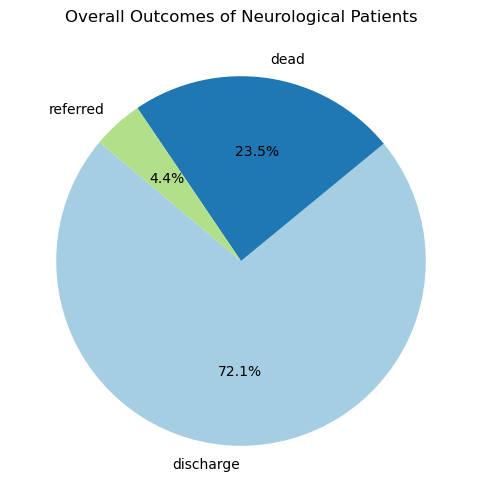

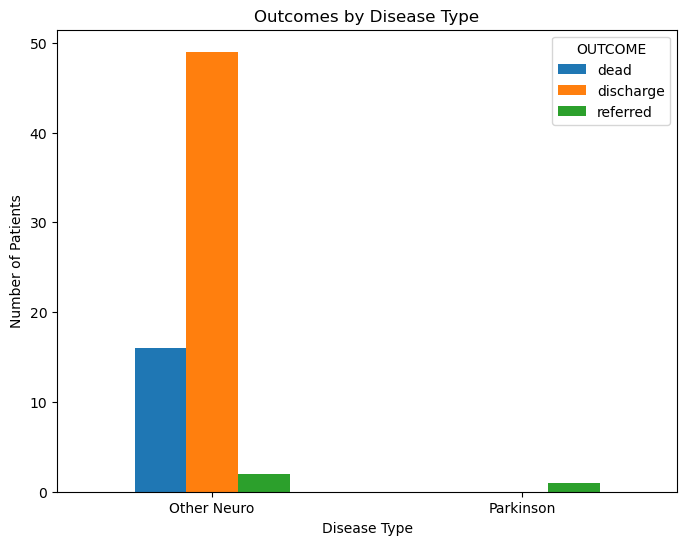

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\2264790911.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\2264790911.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_outcome = neurological_df.groupby(['Age_Group', 'OUTCOME']).size().unstack(fill_value=0)


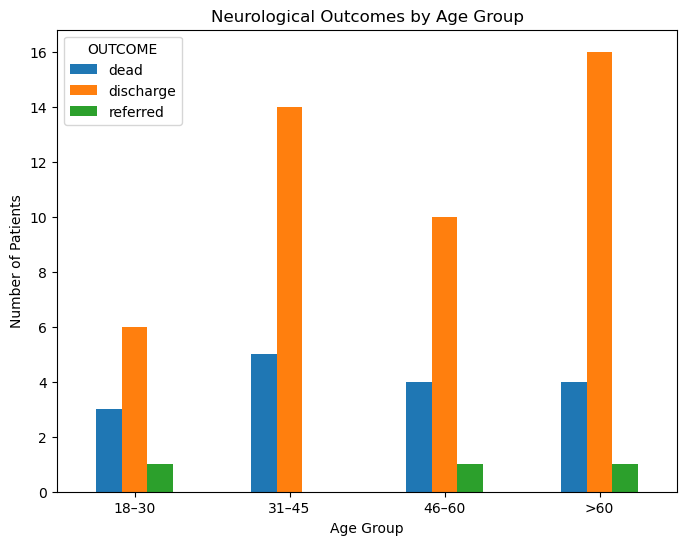

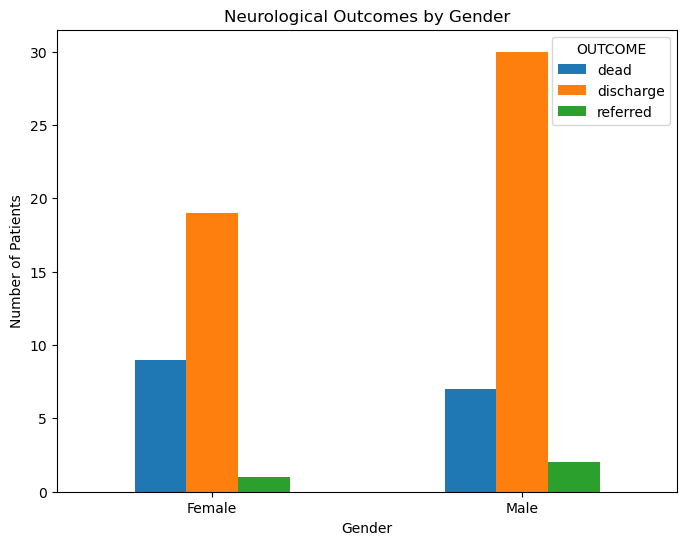

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# Identify neurological patients (reuse Step 6 logic)
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)
neurological_df = df[df['Neurological']]

# Flag Parkinson’s patients
parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# -----------------------------
# 1. Overall Outcomes Table & Pie
# -----------------------------
if 'OUTCOME' in df.columns:
    outcome_counts = neurological_df['OUTCOME'].value_counts()
    outcome_table = outcome_counts.reset_index()
    outcome_table.columns = ['Outcome', 'Number of Patients']
    outcome_table['Percentage'] = (outcome_table['Number of Patients'] / len(neurological_df) * 100).round(2)
    print("\nOverall Neurological Outcomes Table:\n", outcome_table)
    
    # Pie chart
    plt.figure(figsize=(6,6))
    plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.title('Overall Outcomes of Neurological Patients')
    plt.show()
else:
    print("No OUTCOME column found.")

# -----------------------------
# 2. Outcomes by Disease Type (Parkinson vs Other)
# -----------------------------
outcome_disease = neurological_df.groupby(['Parkinson', 'OUTCOME']).size().unstack(fill_value=0)
outcome_disease.index = ['Other Neuro', 'Parkinson']
outcome_disease.plot(kind='bar', figsize=(8,6))
plt.title('Outcomes by Disease Type')
plt.ylabel('Number of Patients')
plt.xlabel('Disease Type')
plt.xticks(rotation=0)
plt.show()

# -----------------------------
# 3. Outcomes by Age Group
# -----------------------------
age_bins = [18, 31, 46, 61, 100]
age_labels = ['18–30', '31–45', '46–60', '>60']
if 'AGE' in df.columns:
    neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_outcome = neurological_df.groupby(['Age_Group', 'OUTCOME']).size().unstack(fill_value=0)
    age_outcome.plot(kind='bar', figsize=(8,6))
    plt.title('Neurological Outcomes by Age Group')
    plt.ylabel('Number of Patients')
    plt.xlabel('Age Group')
    plt.xticks(rotation=0)
    plt.show()

# -----------------------------
# 4. Outcomes by Gender
# -----------------------------
if 'SEX' in df.columns:
    gender_outcome = neurological_df.groupby(['SEX', 'OUTCOME']).size().unstack(fill_value=0)
    gender_outcome.plot(kind='bar', figsize=(8,6))
    plt.title('Neurological Outcomes by Gender')
    plt.ylabel('Number of Patients')
    plt.xlabel('Gender')
    plt.xticks(rotation=0)
    plt.show()

In [13]:
import pandas as pd

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# -----------------------------
# 1. Identify Neurological Patients
# -----------------------------
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)
neurological_df = df[df['Neurological']]

# Flag Parkinson’s patients
parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# -----------------------------
# 2. Overall Outcomes Table
# -----------------------------
if 'OUTCOME' in df.columns:
    outcome_counts = neurological_df['OUTCOME'].value_counts()
    overall_outcome_table = outcome_counts.reset_index()
    overall_outcome_table.columns = ['Outcome', 'Number of Patients']
    overall_outcome_table['Percentage'] = (overall_outcome_table['Number of Patients'] / len(neurological_df) * 100).round(2)
    print("\n1. Overall Neurological Outcomes Table:\n", overall_outcome_table)
else:
    print("No OUTCOME column found.")

# -----------------------------
# 3. Outcomes by Disease Type
# -----------------------------
outcome_disease = neurological_df.groupby(['Parkinson', 'OUTCOME']).size().unstack(fill_value=0)
outcome_disease.index = ['Other Neuro', 'Parkinson']
outcome_disease['Total'] = outcome_disease.sum(axis=1)
outcome_disease_percentage = outcome_disease.div(outcome_disease['Total'], axis=0).mul(100).round(2)
print("\n2. Outcomes by Disease Type Table (Counts):\n", outcome_disease.drop(columns='Total'))
print("\n2b. Outcomes by Disease Type Table (Percentages):\n", outcome_disease_percentage.drop(columns='Total'))

# -----------------------------
# 4. Outcomes by Age Group
# -----------------------------
age_bins = [18, 31, 46, 61, 100]
age_labels = ['18–30', '31–45', '46–60', '>60']
if 'AGE' in df.columns:
    neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_outcome = neurological_df.groupby(['Age_Group', 'OUTCOME']).size().unstack(fill_value=0)
    age_outcome['Total'] = age_outcome.sum(axis=1)
    age_outcome_percentage = age_outcome.div(age_outcome['Total'], axis=0).mul(100).round(2)
    print("\n3. Outcomes by Age Group Table (Counts):\n", age_outcome.drop(columns='Total'))
    print("\n3b. Outcomes by Age Group Table (Percentages):\n", age_outcome_percentage.drop(columns='Total'))

# -----------------------------
# 5. Outcomes by Gender
# -----------------------------
if 'SEX' in df.columns:
    gender_outcome = neurological_df.groupby(['SEX', 'OUTCOME']).size().unstack(fill_value=0)
    gender_outcome['Total'] = gender_outcome.sum(axis=1)
    gender_outcome_percentage = gender_outcome.div(gender_outcome['Total'], axis=0).mul(100).round(2)
    print("\n4. Outcomes by Gender Table (Counts):\n", gender_outcome.drop(columns='Total'))
    print("\n4b. Outcomes by Gender Table (Percentages):\n", gender_outcome_percentage.drop(columns='Total'))


1. Overall Neurological Outcomes Table:
      Outcome  Number of Patients  Percentage
0  discharge                  49       72.06
1       dead                  16       23.53
2   referred                   3        4.41

2. Outcomes by Disease Type Table (Counts):
 OUTCOME      dead  discharge  referred
Other Neuro    16         49         2
Parkinson       0          0         1

2b. Outcomes by Disease Type Table (Percentages):
 OUTCOME       dead  discharge  referred
Other Neuro  23.88      73.13      2.99
Parkinson     0.00       0.00    100.00

3. Outcomes by Age Group Table (Counts):
 OUTCOME    dead  discharge  referred
Age_Group                           
18–30         3          6         1
31–45         5         14         0
46–60         4         10         1
>60           4         16         1

3b. Outcomes by Age Group Table (Percentages):
 OUTCOME     dead  discharge  referred
Age_Group                            
18–30      30.00      60.00     10.00
31–45      26.3

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\1775732278.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\1775732278.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_10404\1775732278.py:54: FutureWarn

## visualization

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\271293313.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\271293313.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\271293313.py:37: FutureWarning

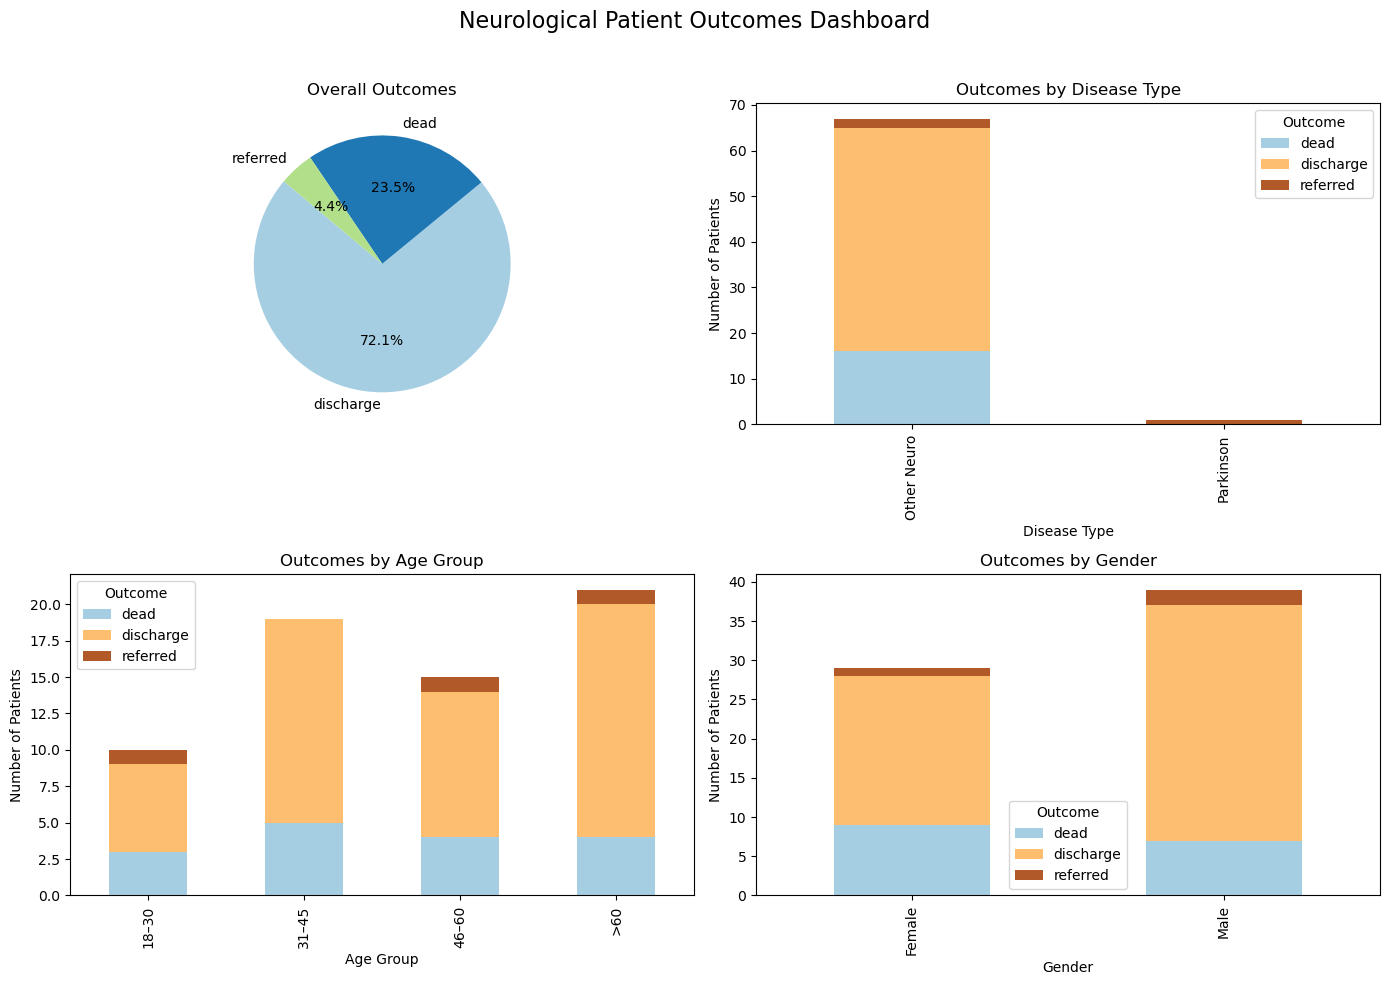

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# Identify neurological patients
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)
neurological_df = df[df['Neurological']]

# Flag Parkinson’s patients
parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# -----------------------------
# Prepare Data
# -----------------------------
if 'OUTCOME' in df.columns:
    outcome_counts = neurological_df['OUTCOME'].value_counts()

outcome_disease = neurological_df.groupby(['Parkinson', 'OUTCOME']).size().unstack(fill_value=0)
outcome_disease.index = ['Other Neuro', 'Parkinson']

if 'AGE' in df.columns:
    age_bins = [18, 31, 46, 61, 100]
    age_labels = ['18–30', '31–45', '46–60', '>60']
    neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_outcome = neurological_df.groupby(['Age_Group', 'OUTCOME']).size().unstack(fill_value=0)

if 'SEX' in df.columns:
    gender_outcome = neurological_df.groupby(['SEX', 'OUTCOME']).size().unstack(fill_value=0)

# -----------------------------
# Plot all charts in one figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Neurological Patient Outcomes Dashboard", fontsize=16)

# 1. Overall Outcomes Pie
axes[0,0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[0,0].set_title('Overall Outcomes')

# 2. Outcomes by Disease Type Bar
outcome_disease.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='Paired')
axes[0,1].set_title('Outcomes by Disease Type')
axes[0,1].set_xlabel('Disease Type')
axes[0,1].set_ylabel('Number of Patients')
axes[0,1].legend(title='Outcome')

# 3. Outcomes by Age Group Bar
age_outcome.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='Paired')
axes[1,0].set_title('Outcomes by Age Group')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Number of Patients')
axes[1,0].legend(title='Outcome')

# 4. Outcomes by Gender Bar
gender_outcome.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='Paired')
axes[1,1].set_title('Outcomes by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Number of Patients')
axes[1,1].legend(title='Outcome')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\1477804080.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\1477804080.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_11220\1477804080.py:41: FutureWarn


Overall Neurological Outcomes Table:
      Outcome  Number of Patients  Percentage
0  discharge                  49       72.06
1       dead                  16       23.53
2   referred                   3        4.41


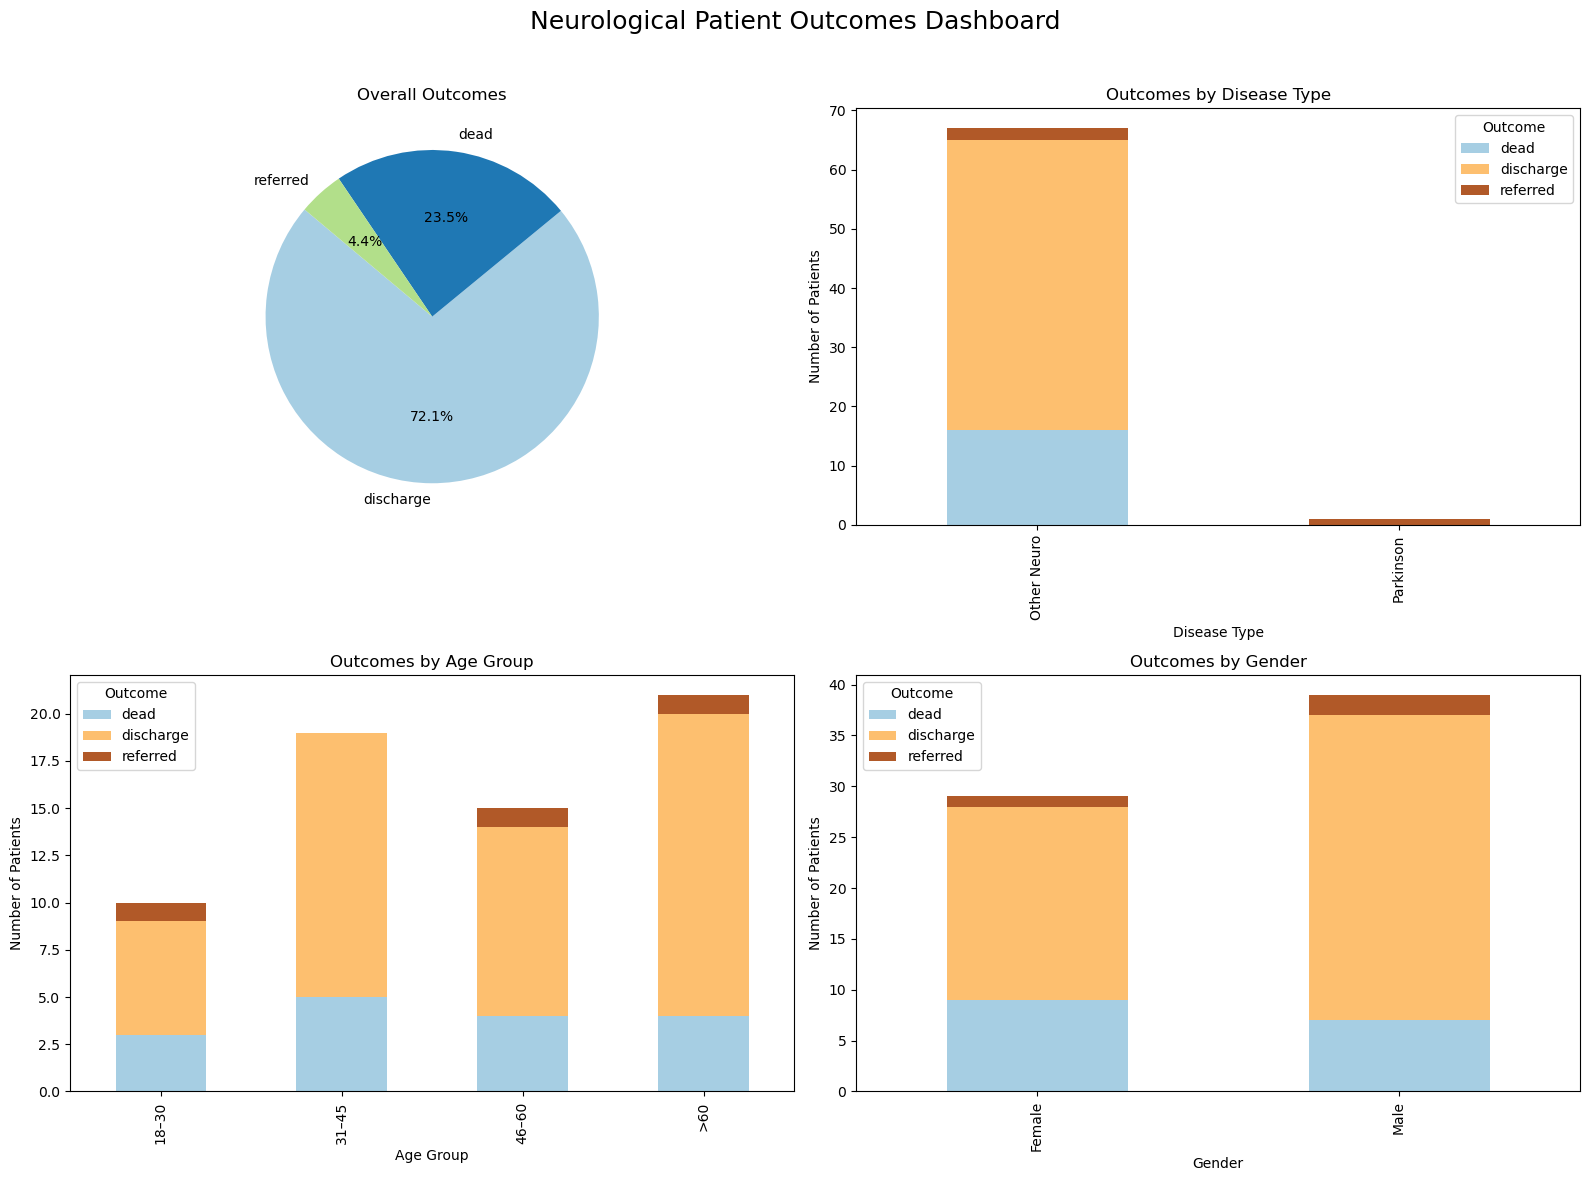

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"C:\Users\MAXWELL OJWANG\Desktop\MAXWELL\PYTHON\REFERENCE\Parkinson's Study - Disease cleaned.csv"
df = pd.read_csv(file_path)

# Detect diagnosis columns
diagnosis_cols = [col for col in df.columns if 'dx' in col.lower() or 'diagnosis' in col.lower()]

# Identify neurological patients
neurological_keywords = ['stroke', 'seizure', 'encephalitis', 'parkinson', 'neuropathy']
df['Neurological'] = df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(neurological_keywords), na=False)), axis=1
)
neurological_df = df[df['Neurological']]

# Flag Parkinson’s patients
parkinson_keywords = ['parkinson']
neurological_df['Parkinson'] = neurological_df[diagnosis_cols].apply(
    lambda x: any(x.str.lower().str.contains('|'.join(parkinson_keywords), na=False)), axis=1
)

# -----------------------------
# Prepare Data
# -----------------------------
if 'OUTCOME' in df.columns:
    outcome_counts = neurological_df['OUTCOME'].value_counts()
    outcome_table = outcome_counts.reset_index()
    outcome_table.columns = ['Outcome', 'Number of Patients']
    outcome_table['Percentage'] = (outcome_table['Number of Patients'] / len(neurological_df) * 100).round(2)
    print("\nOverall Neurological Outcomes Table:\n", outcome_table)

outcome_disease = neurological_df.groupby(['Parkinson', 'OUTCOME']).size().unstack(fill_value=0)
outcome_disease.index = ['Other Neuro', 'Parkinson']

if 'AGE' in df.columns:
    age_bins = [18, 31, 46, 61, 100]
    age_labels = ['18–30', '31–45', '46–60', '>60']
    neurological_df['Age_Group'] = pd.cut(neurological_df['AGE'], bins=age_bins, labels=age_labels, right=False)
    age_outcome = neurological_df.groupby(['Age_Group', 'OUTCOME']).size().unstack(fill_value=0)

if 'SEX' in df.columns:
    gender_outcome = neurological_df.groupby(['SEX', 'OUTCOME']).size().unstack(fill_value=0)

# -----------------------------
# Plot all charts in one figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle("Neurological Patient Outcomes Dashboard", fontsize=18)

# 1. Overall Outcomes Pie
axes[0,0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[0,0].set_title('Overall Outcomes')

# 2. Outcomes by Disease Type Bar
outcome_disease.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='Paired')
axes[0,1].set_title('Outcomes by Disease Type')
axes[0,1].set_xlabel('Disease Type')
axes[0,1].set_ylabel('Number of Patients')
axes[0,1].legend(title='Outcome')

# 3. Outcomes by Age Group Bar
age_outcome.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='Paired')
axes[1,0].set_title('Outcomes by Age Group')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Number of Patients')
axes[1,0].legend(title='Outcome')

# 4. Outcomes by Gender Bar
gender_outcome.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='Paired')
axes[1,1].set_title('Outcomes by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Number of Patients')
axes[1,1].legend(title='Outcome')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()